DBSCAN Clustering — Repair Invoice Anomaly

In [1]:
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import seaborn as sns; from sklearn.preprocessing import StandardScaler, OneHotEncoder; from sklearn.cluster import DBSCAN; from sklearn.compose import ColumnTransformer; from sklearn.decomposition import PCA; from sklearn.neighbors import NearestNeighbors; from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [2]:
df = pd.read_csv('repair_invoice_clean.csv')
df.head()

,repair_id,claim_id,vehicle_id,repair_shop_contact_id,estimate_amount,approved_amount,invoice_amount,paid_amount,repair_start_date,repair_end_date,...,exposure_status,is_repeat_vehicle,is_synthetic_anomaly,anomaly_type,vehicle_claim_count,repair_duration_days,vehicle_age,invoice_vs_estimate_ratio,invoice_vs_approved_ratio,duplicate_flag
0,1,1,5749,217,883.00,859.88,821.28,779.60,2025-11-16,2025-11-18,...,Open,False,False,NaN,1,2,13,0.930102,0.955110,True
1,2,2,1818,152,1659.62,1620.74,1627.69,1621.15,2026-02-23,2026-03-02,...,Closed,False,False,NaN,1,7,6,0.980761,1.004288,False
2,7,6,4529,175,1013.25,844.58,917.77,820.13,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,0.905769,1.086658,False
3,8,6,4529,175,1231.42,1213.63,1417.89,1211.47,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,1.151427,1.168305,False
4,9,7,7329,180,2946.86,3039.04,2827.41,2918.91,2025-11-23,2025-11-29,...,Closed,False,False,NaN,1,6,4,0.959465,0.930363,False


In [3]:
NUMERIC_FEATURES = [
   "invoice_amount", "estimate_amount",
   "vehicle_age", "liability_percentage",
]
CATEGORICAL_FEATURES = [
   "make", "damage_severity", "claim_severity", "incident_type",
   "incident_state", "coverage_type",
]

In [4]:
preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])
X = preprocessor.fit_transform(df)

In [5]:
X = X.toarray() if hasattr(X, "toarray") else X
X.shape

(6456, 34)

Choosing `eps` and `min_samples`

In [6]:
MIN_SAMPLES = 2 * X.shape[1]
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)

In [7]:
neighbors.fit(X)
nn_distances, _ = neighbors.kneighbors(X)

In [8]:
k_distances = np.sort(nn_distances[:, -1])  # distance to the MIN_SAMPLES-th neighbor; fig, ax = plt.subplots(figsize=(9, 5)); ax.plot(k_distances); ax.set_title(f"k-distance graph (k={MIN_SAMPLES})"); ax.set_xlabel("points, sorted by distance"); ax.set_ylabel(f"distance to {MIN_SAMPLES}th nearest neighbor"); ax.grid(alpha=0.3); plt.tight_layout(); plt.show(); print(f"MIN_SAMPLES = {MIN_SAMPLES}")

In [9]:
print("Percentiles of k-distance (candidates for eps):")
for p in [80, 85, 90, 92, 95, 97, 99]:
    print(f"  p{p}: {np.percentile(k_distances, p):.3f}")

Percentiles of k-distance (candidates for eps):
  p80: 2.166
  p85: 2.236
  p90: 2.370
  p92: 2.438
  p95: 2.563
  p97: 2.728
  p99: 3.440


The `min_samples = 2 * D

In [10]:
grid_results = []
for min_samples in [8, 10, 12, 15]:
    for eps in [1.3, 1.4, 1.5, 1.55, 1.6, 1.65, 1.7]:
        lbl = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_pct = (lbl == -1).mean() * 100
        sil = np.nan
        if n_clusters >= 2:
            mask = lbl != -1
            if mask.sum() > n_clusters:
                sil = silhouette_score(X[mask], lbl[mask])
        grid_results.append((min_samples, eps, n_clusters, noise_pct, sil))

In [11]:
grid_df = pd.DataFrame(grid_results, columns=["min_samples", "eps", "n_clusters", "noise_pct", "silhouette"])
candidates = grid_df[(grid_df["n_clusters"].between(3, 10)) & (grid_df["noise_pct"].between(5, 20))]

In [12]:
candidates.sort_values("silhouette", ascending=False).head(10)

,min_samples,eps,n_clusters,noise_pct,silhouette
5,8,1.65,6,8.813507,0.181297
4,8,1.60,5,11.322800,0.173314
13,10,1.70,6,7.853160,0.167857
20,12,1.70,4,9.587980,0.136971
12,10,1.65,5,10.749690,0.125777
17,12,1.55,3,19.377323,0.003233
3,8,1.55,6,14.296778,-0.031240


In [13]:
EPS = 1.65
MIN_SAMPLES = 8  # overrides the 2*D starting heuristic above based on the grid search

In [14]:
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels = dbscan.fit_predict(X)

In [15]:
df["cluster"] = labels
df["dbscan_flag"] = labels == -1  # DBSCAN's own noise label doubles as the anomaly flag

In [16]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"clusters found: {n_clusters}")

clusters found: 6


In [17]:
print(f"noise points (flagged): {(labels == -1).sum()} ({(labels == -1).mean():.1%})")
df["dbscan_flag"].value_counts()

noise points (flagged): 569 (8.8%)


dbscan_flag
False    5887
True      569
Name: count, dtype: int64

Evaluation metrics

In [18]:
mask = labels != -1
X_clustered, labels_clustered = X[mask], labels[mask]

In [19]:
sil = silhouette_score(X_clustered, labels_clustered)
db = davies_bouldin_score(X_clustered, labels_clustered)

In [20]:
ch = calinski_harabasz_score(X_clustered, labels_clustered)


In [21]:
print(f"Silhouette score:        {sil:.3f}")
print(f"Davies-Bouldin index:    {db:.3f}")
print(f"Calinski-Harabasz index: {ch:.1f}")

Silhouette score:        0.181
Davies-Bouldin index:    1.246
Calinski-Harabasz index: 25.6


In [22]:
cluster_sizes = df.loc[df["cluster"] != -1, "cluster"].value_counts().sort_index()
cluster_sizes.name = "count"

In [23]:
cluster_sizes.to_frame()

,count
cluster,
0,5834
1,9
2,22
3,8
4,8
5,6


Visualization

In [24]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

In [25]:
df["pca_1"] = X_2d[:, 0]
df["pca_2"] = X_2d[:, 1]

In [26]:
explained = pca.explained_variance_ratio_
print(f"Explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, total={explained.sum():.1%}")

Explained variance: PC1=29.4%, PC2=14.3%, total=43.8%


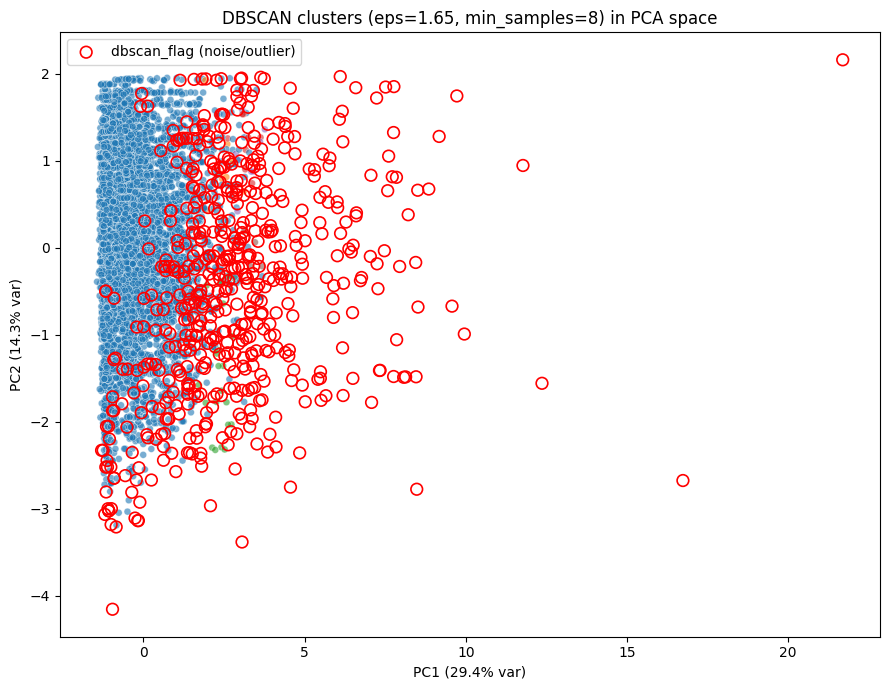

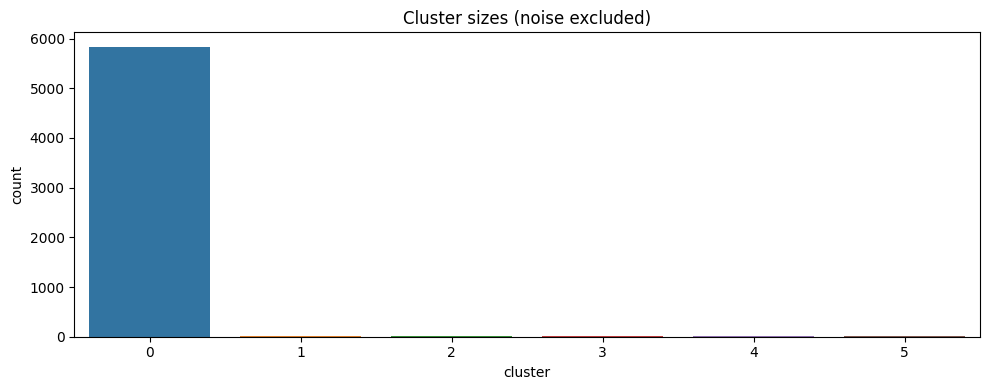

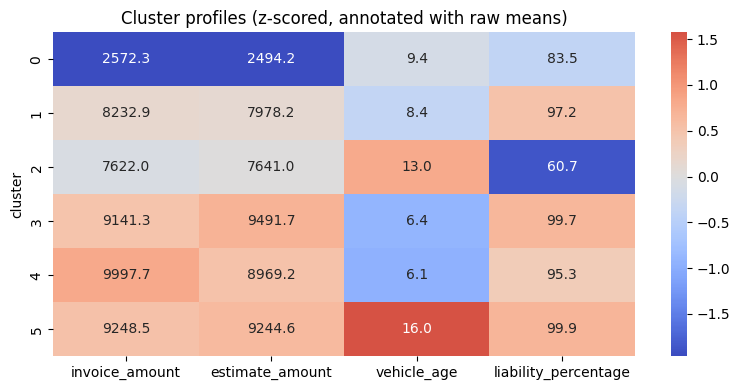

In [27]:
fig, ax = plt.subplots(figsize=(9, 7)); normal = df[~df["dbscan_flag"]]; flagged = df[df["dbscan_flag"]]; sns.scatterplot(
    data=normal, x="pca_1", y="pca_2", hue="cluster",
    palette="tab10", s=25, alpha=0.6, legend=False, ax=ax,
); ax.scatter(
    flagged["pca_1"], flagged["pca_2"],
    facecolors="none", edgecolors="red", s=70, linewidths=1.2,
    label="dbscan_flag (noise/outlier)",
); ax.set_title(f"DBSCAN clusters (eps={EPS}, min_samples={MIN_SAMPLES}) in PCA space"); ax.set_xlabel(f"PC1 ({explained[0]:.1%} var)"); ax.set_ylabel(f"PC2 ({explained[1]:.1%} var)"); ax.legend(); plt.tight_layout(); plt.show(); fig, ax = plt.subplots(figsize=(10, 4)); sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, hue=cluster_sizes.index, palette="tab10", legend=False, ax=ax); ax.set_title("Cluster sizes (noise excluded)"); ax.set_xlabel("cluster"); ax.set_ylabel("count"); plt.tight_layout(); plt.show(); profile = df.loc[df["cluster"] != -1].groupby("cluster")[NUMERIC_FEATURES].mean(); fig, ax = plt.subplots(figsize=(8, 4)); sns.heatmap(
    (profile - profile.mean()) / profile.std(),
    cmap="coolwarm", center=0, annot=profile.round(1), fmt="", ax=ax,
); ax.set_title("Cluster profiles (z-scored, annotated with raw means)"); plt.tight_layout(); plt.show()

Anomaly-flag sanity checks

In [28]:
ct = pd.crosstab(df["dbscan_flag"], df["duplicate_flag"], normalize="index")
print("duplicate_flag rate within each dbscan_flag group:")

duplicate_flag rate within each dbscan_flag group:


In [29]:
print(ct.round(3))
overlap_rate = df.loc[df["dbscan_flag"], "duplicate_flag"].mean()

duplicate_flag  False  True 
dbscan_flag                 
False           0.920  0.080
True            0.919  0.081


In [30]:
base_rate = df["duplicate_flag"].mean()
print(f"\nduplicate_flag rate among dbscan-flagged rows: {overlap_rate:.1%}")


duplicate_flag rate among dbscan-flagged rows: 8.1%


duplicate_flag rate overall:                   8.0%


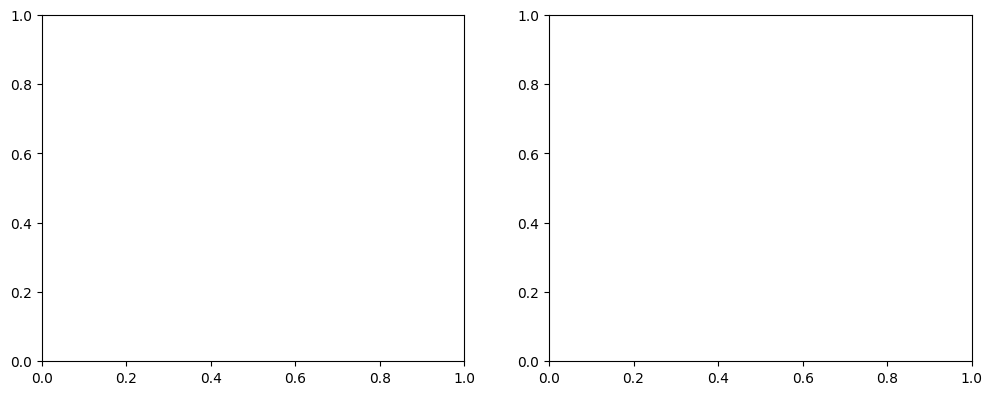

In [31]:
print(f"duplicate_flag rate overall:                   {base_rate:.1%}"); fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

In [32]:
for ax, col in zip(axes, ["invoice_vs_estimate_ratio", "invoice_vs_approved_ratio"]):
    sns.boxplot(data=df, x="dbscan_flag", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [33]:
plt.show()

Scoring a new data point

In [34]:
core_points = dbscan.components_  # coordinates of every core sample found during fit
core_labels = labels[dbscan.core_sample_indices_]  # each core sample's cluster label

In [35]:
def score_new_point(record: dict) -> dict:
    """Score a single new repair-invoice record against the fitted DBSCAN model.

    `record` must contain the same NUMERIC_FEATURES + CATEGORICAL_FEATURES keys
    used to fit `preprocessor`.
    """
    row = pd.DataFrame([record])[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

    x_new = preprocessor.transform(row)
    x_new = x_new.toarray() if hasattr(x_new, "toarray") else x_new
    x_new = x_new[0]

    dists_to_core = np.linalg.norm(core_points - x_new, axis=1)
    within_eps = dists_to_core <= EPS

    if not within_eps.any():
        cluster = -1
        nearest_core_distance = float(dists_to_core.min())
    else:
        # assign to the cluster of the nearest in-range core sample
        nearest_idx = np.argmin(np.where(within_eps, dists_to_core, np.inf))
        cluster = int(core_labels[nearest_idx])
        nearest_core_distance = float(dists_to_core[nearest_idx])

    return {
        "cluster": cluster,
        "nearest_core_distance": nearest_core_distance,
        "eps": EPS,
        "dbscan_flag": cluster == -1,
        "pca_coords": pca.transform(x_new.reshape(1, -1))[0].tolist(),
    }

In [36]:
typical_point = {
    "invoice_amount": 2320.00,
    "estimate_amount": 2265.50,
    "vehicle_age": 9,
    "liability_percentage": 85.0,
    "make": "Toyota",
    "damage_severity": "Moderate",
    "claim_severity": "Medium",
    "incident_type": "Vehicle Accident",
    "incident_state": "CA",
    "coverage_type": "Liability",
}
suspicious_point = {
    "invoice_amount": 18250.00,   # invoice ~7.6x the estimate for "Minor" damage
    "estimate_amount": 2400.00,
    "vehicle_age": 2,
    "liability_percentage": 22.0,
    "make": "Tesla",
    "damage_severity": "Minor",
    "claim_severity": "Low",
    "incident_type": "Vehicle Accident",
    "incident_state": "CA",
    "coverage_type": "Liability",
}

In [37]:
for name, point in [("typical_point", typical_point), ("suspicious_point", suspicious_point)]:
    result = score_new_point(point)
    print(f"--- {name} ---")
    for k, v in result.items():
        if k == "pca_coords":
            continue
        print(f"  {k}: {v}")
    print()

--- typical_point ---
  cluster: 0
  nearest_core_distance: 0.34562473081706485
  eps: 1.65
  dbscan_flag: False

--- suspicious_point ---
  cluster: -1
  nearest_core_distance: 5.256693788232193
  eps: 1.65
  dbscan_flag: True



<Axes: xlabel='pca_1', ylabel='pca_2'>

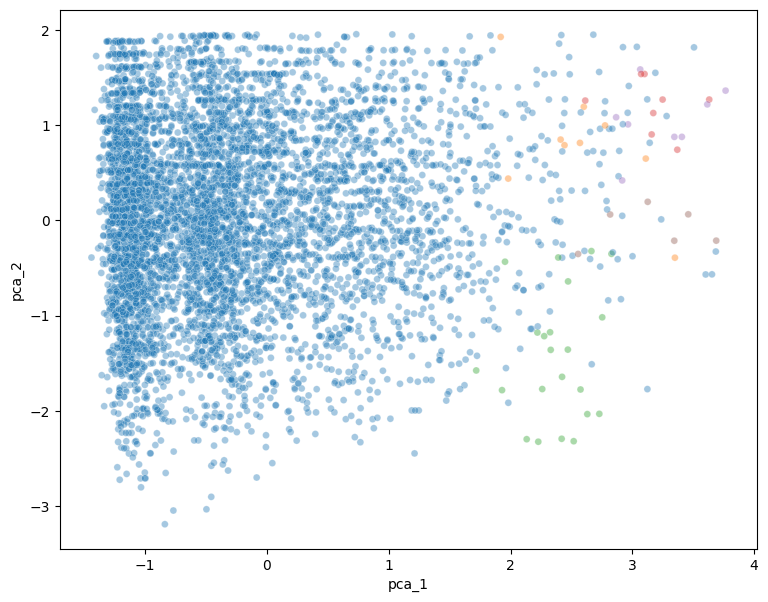

In [38]:
fig, ax = plt.subplots(figsize=(9, 7)); sns.scatterplot(
    data=df[df["cluster"] != -1], x="pca_1", y="pca_2", hue="cluster",
    palette="tab10", s=25, alpha=0.4, legend=False, ax=ax,
)

In [39]:
sns.scatterplot(
    data=df[df["cluster"] == -1], x="pca_1", y="pca_2",
    color="gray", marker="x", s=25, alpha=0.4, ax=ax, label="noise (training)",
)
for name, point, marker, color in [
    ("typical_point", typical_point, "*", "limegreen"),
    ("suspicious_point", suspicious_point, "X", "red"),
]:
    r = score_new_point(point)
    px, py = r["pca_coords"]
    ax.scatter(px, py, marker=marker, s=400, color=color, edgecolors="black", linewidths=1, label=f"{name} (flag={r['dbscan_flag']})", zorder=5)

In [40]:
ax.set_title("New points scored against fitted DBSCAN clusters"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(); plt.tight_layout(); plt.show()

<Figure size 640x480 with 0 Axes>